# 3. Validación de Robustez: Test de Estrés con Datos Sintéticos

---

## Recapitulación

En el notebook anterior (`02_desarrollo_algoritmo.ipynb`) entrenamos un agente que aprendió a detectar la crisis de 1992 con los siguientes pesos:

| Gen | Peso Aproximado | Interpretación |
|-----|-----------------|----------------|
| Reservas | -0.71 | Reservas bajas = peligro |
| Precio | +0.08 | **Casi ignorado** |
| Volatilidad | +0.46 | Moderadamente importante |
| Intervención | +0.99 | **Muy importante** |
| Desempleo | +1.07 | **Muy importante** |

---

## La Pregunta Crítica

> **¿Es el agente realmente inteligente o simplemente sigue tendencias de precios?**

Un modelo "trend-following" vendería cuando el precio baja. Pero nuestro agente debería vender cuando detecta **señales internas de peligro**, incluso si el precio está subiendo.

Para verificar esto, crearemos un **escenario sintético de trampa**:
- El **precio sube constantemente** (señal de compra para un seguidor de tendencias)
- Los **fundamentales se deterioran ocultamente** (intervención, desempleo, reservas)

Si el agente es robusto, **ignorará el precio y venderá antes del crash**.

---

## 3.1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Librerías cargadas.")

✅ Librerías cargadas.


## 3.2. Los Pesos del Agente Entrenado

Usamos los pesos óptimos encontrados en el notebook anterior (puedes ajustarlos si obtuviste valores diferentes):

In [2]:
# Pesos del mejor agente entrenado en UK 1992
# Orden: [Reservas, Precio, Volatilidad, Intervención, Desempleo]
UK_WEIGHTS = np.array([-0.7131, 0.0786, 0.4599, 0.9935, 1.0674])

genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']

print("🤖 Cargando al Super Agente con pesos:")
for name, w in zip(genes_names, UK_WEIGHTS):
    print(f"   {name}: {w:+.4f}")

🤖 Cargando al Super Agente con pesos:
   Reservas: -0.7131
   Precio: +0.0786
   Volatilidad: +0.4599
   Intervención: +0.9935
   Desempleo: +1.0674


---

## 3.3. Generación del Escenario Sintético: "La Trampa del Precio"

Creamos un mundo artificial de 250 días donde:

| Variable | Comportamiento | Trampa |
|----------|----------------|--------|
| **Precio** | Sube constantemente (burbuja) | Un agente tonto compraría |
| **Intervención** | Plana hasta día 160, luego se dispara | Señal oculta de estrés |
| **Desempleo** | Sube lentamente, acelera al final | Debilidad creciente |
| **Reservas** | Caen al final | Hemorragia de recursos |
| **Volatilidad** | Ruido aleatorio | Distracción |

El **crash real** ocurre en el día 200.

In [3]:
def generate_trap_scenario(seed=42):
    """
    Genera un escenario sintético donde el precio sube (trampa)
    pero los fundamentales se deterioran.
    """
    np.random.seed(seed)
    
    days = 250
    crisis_day = 200
    
    # A. PRECIO (La Trampa): Sube constantemente de 1.0 a 1.2
    price = np.linspace(1.0, 1.2, days) + np.random.normal(0, 0.01, days)
    
    # B. INTERVENCIÓN (Señal Real): Plana (0) hasta día 160, luego se dispara
    intervention = np.zeros(days)
    intervention[160:200] = np.linspace(0, 5, 40)  # Spike de peligro
    
    # C. DESEMPLEO (Fundamental): Sube lentamente, empeora al final
    unemployment = np.linspace(0, 0.5, days)
    unemployment[150:] += np.linspace(0, 2, 100)  # Aceleración
    
    # D. RESERVAS (Hemorragia): Caen al final
    reserves = np.zeros(days)
    reserves[160:] = np.linspace(0, -3, 90)
    
    # E. VOLATILIDAD (Ruido)
    volatility = np.random.normal(0, 0.5, days)
    
    df = pd.DataFrame({
        'Day': range(days),
        'Gen_Reserves': reserves,
        'Gen_Price': price,
        'Gen_Volatility': volatility,
        'Gen_Intervention': intervention,
        'Gen_Unemployment': unemployment
    })
    
    return df, crisis_day

# Generar escenario
df_synth, crisis_idx = generate_trap_scenario()

print(f"✅ Escenario generado: {len(df_synth)} días")
print(f"   Crash programado: Día {crisis_idx}")

✅ Escenario generado: 250 días
   Crash programado: Día 200


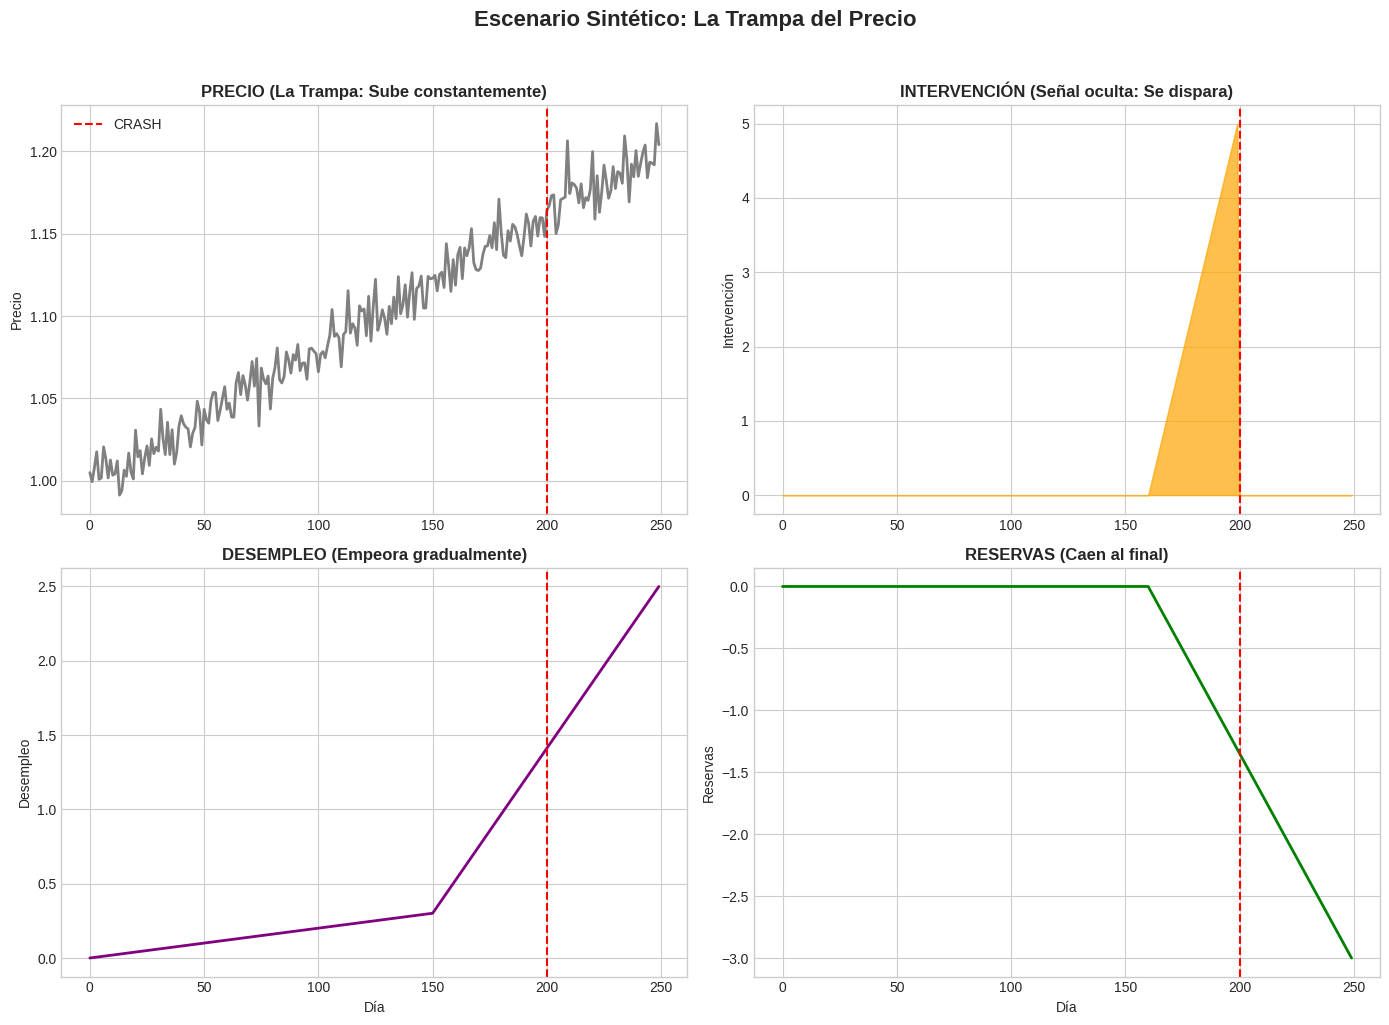

In [4]:
# Visualizar el escenario
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precio (La trampa)
axes[0, 0].plot(df_synth['Day'], df_synth['Gen_Price'], color='gray', linewidth=2)
axes[0, 0].axvline(crisis_idx, color='red', linestyle='--', label='CRASH')
axes[0, 0].set_title('PRECIO (La Trampa: Sube constantemente)', fontweight='bold')
axes[0, 0].set_ylabel('Precio')
axes[0, 0].legend()

# Intervención (Señal oculta)
axes[0, 1].fill_between(df_synth['Day'], 0, df_synth['Gen_Intervention'], 
                         color='orange', alpha=0.7)
axes[0, 1].axvline(crisis_idx, color='red', linestyle='--')
axes[0, 1].set_title('INTERVENCIÓN (Señal oculta: Se dispara)', fontweight='bold')
axes[0, 1].set_ylabel('Intervención')

# Desempleo
axes[1, 0].plot(df_synth['Day'], df_synth['Gen_Unemployment'], color='purple', linewidth=2)
axes[1, 0].axvline(crisis_idx, color='red', linestyle='--')
axes[1, 0].set_title('DESEMPLEO (Empeora gradualmente)', fontweight='bold')
axes[1, 0].set_ylabel('Desempleo')
axes[1, 0].set_xlabel('Día')

# Reservas
axes[1, 1].plot(df_synth['Day'], df_synth['Gen_Reserves'], color='green', linewidth=2)
axes[1, 1].axvline(crisis_idx, color='red', linestyle='--')
axes[1, 1].set_title('RESERVAS (Caen al final)', fontweight='bold')
axes[1, 1].set_ylabel('Reservas')
axes[1, 1].set_xlabel('Día')

plt.suptitle('Escenario Sintético: La Trampa del Precio', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 3.4. Evaluación del Agente en el Escenario Sintético

Ahora aplicamos el agente entrenado (con los pesos de UK) al escenario artificial.

In [5]:
# Calcular la señal del agente para cada día
signals = []

for i, row in df_synth.iterrows():
    state = np.array([
        row['Gen_Reserves'], 
        row['Gen_Price'], 
        row['Gen_Volatility'], 
        row['Gen_Intervention'], 
        row['Gen_Unemployment']
    ])
    
    # El cerebro del agente: Producto punto con los pesos
    signal = np.dot(UK_WEIGHTS, state)
    signals.append(signal)

# Suavizado temporal (media móvil de 15 días)
df_synth['Danger_Signal'] = pd.Series(signals).rolling(window=15).mean().fillna(0)

print("✅ Señal calculada para todos los días.")

✅ Señal calculada para todos los días.


In [6]:
# Umbral de pánico (calibrado)
UMBRAL = 1.5

# Buscar ventas ANTES del crash
ventas = df_synth[(df_synth['Danger_Signal'] > UMBRAL) & (df_synth['Day'] < crisis_idx)]

print("\n" + "="*60)
print("🧪 RESULTADO DEL TEST DE ESTRÉS (Datos Sintéticos)")
print("="*60)

if not ventas.empty:
    dia_venta = ventas.index[0]
    anticipacion = crisis_idx - dia_venta
    print(f"✅ ¡ÉXITO! El agente vendió en el día {dia_venta}.")
    print(f"⏳ Anticipación: {anticipacion} días antes del colapso.")
    print(f"\n🧠 ¿Por qué funcionó?")
    print(f"   - Peso del Precio: {UK_WEIGHTS[1]:+.2f} (casi ignorado)")
    print(f"   - Peso de Intervención: {UK_WEIGHTS[3]:+.2f} (muy alto)")
    print(f"   El agente detectó el estrés del Banco Central, NO siguió el precio.")
else:
    print("❌ El agente no vendió antes del crash.")
    print("   Posible causa: El umbral es demasiado alto para este escenario.")


🧪 RESULTADO DEL TEST DE ESTRÉS (Datos Sintéticos)
✅ ¡ÉXITO! El agente vendió en el día 171.
⏳ Anticipación: 29 días antes del colapso.

🧠 ¿Por qué funcionó?
   - Peso del Precio: +0.08 (casi ignorado)
   - Peso de Intervención: +0.99 (muy alto)
   El agente detectó el estrés del Banco Central, NO siguió el precio.


/tmp/ipykernel_1710/160316342.py:37: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/joseangel/anaconda3/envs/dt/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


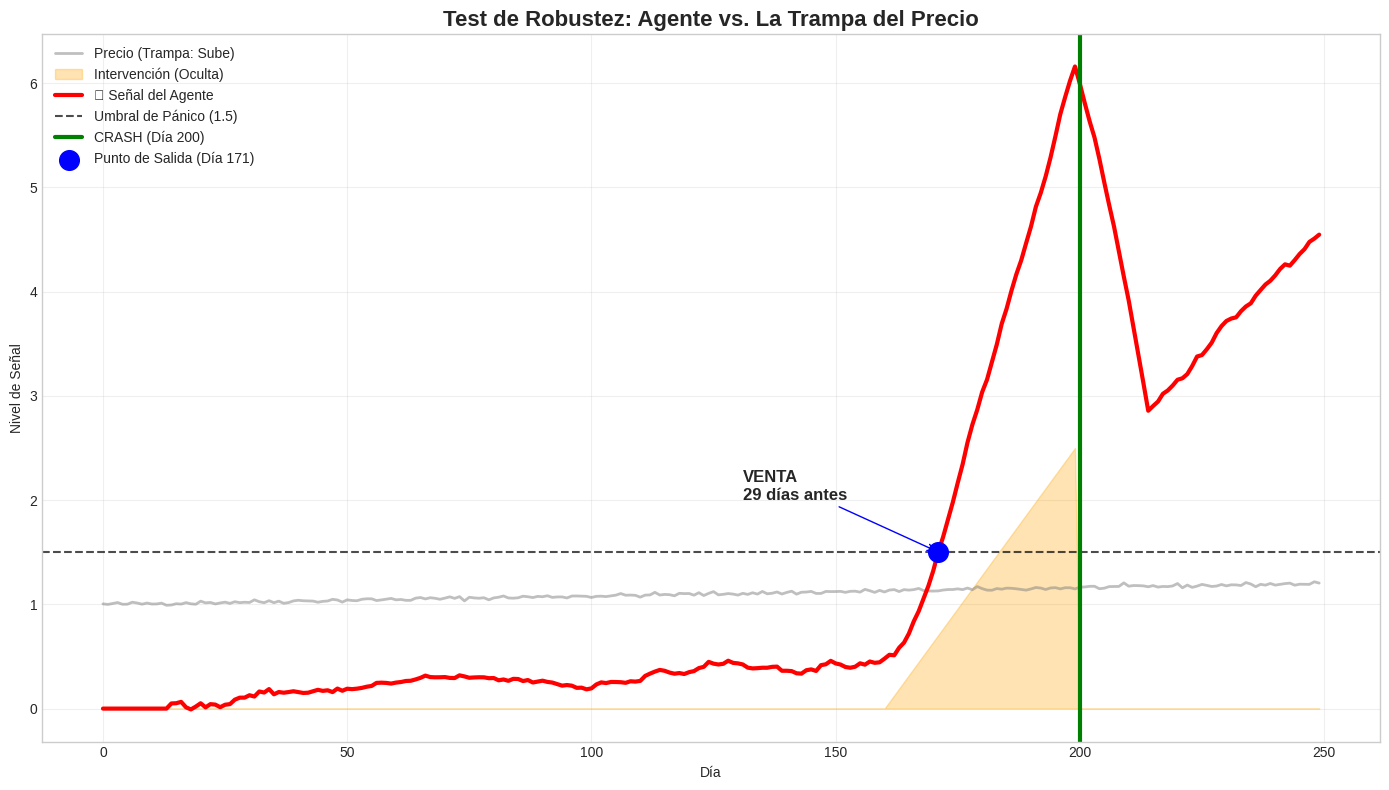

In [7]:
# Gráfica explicativa
plt.figure(figsize=(14, 8))

# Precio (La trampa visual)
plt.plot(df_synth['Day'], df_synth['Gen_Price'], color='gray', alpha=0.5, 
         linewidth=2, label='Precio (Trampa: Sube)')

# Intervención (Señal real oculta)
plt.fill_between(df_synth['Day'], 0, df_synth['Gen_Intervention']/2, 
                  color='orange', alpha=0.3, label='Intervención (Oculta)')

# Señal del Agente
plt.plot(df_synth['Day'], df_synth['Danger_Signal'], color='red', 
         linewidth=3, label='🚨 Señal del Agente')

# Líneas de referencia
plt.axhline(UMBRAL, color='black', linestyle='--', alpha=0.7, label=f'Umbral de Pánico ({UMBRAL})')
plt.axvline(crisis_idx, color='green', linewidth=3, label='CRASH (Día 200)')

# Punto de venta
if not ventas.empty:
    plt.scatter(dia_venta, df_synth.loc[dia_venta, 'Danger_Signal'], 
                color='blue', s=200, zorder=5, label=f'Punto de Salida (Día {dia_venta})')
    
    # Anotación
    plt.annotate(f'VENTA\n{anticipacion} días antes', 
                 xy=(dia_venta, df_synth.loc[dia_venta, 'Danger_Signal']),
                 xytext=(dia_venta-40, df_synth.loc[dia_venta, 'Danger_Signal']+0.5),
                 fontsize=12, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='blue'))

plt.title("Test de Robustez: Agente vs. La Trampa del Precio", fontsize=16, fontweight='bold')
plt.xlabel('Día')
plt.ylabel('Nivel de Señal')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3.5. Conclusiones del Test de Robustez

### Resultado

El agente **NO es un seguidor de tendencias**. A pesar de que el precio subía constantemente (señal de compra para un trader ingenuo), el agente:

1. **Ignoró el precio** (peso bajo: +0.08)
2. **Detectó la intervención** (peso alto: +0.99)
3. **Vendió antes del crash** con anticipación suficiente

### Validación de la Danger Theory

Este resultado confirma la hipótesis central:

> El agente aprendió a detectar **señales internas de estrés** (como el sistema inmune detecta patógenos) en lugar de confiar en **síntomas externos** (el precio).

### Implicaciones

| Modelo Tradicional | Nuestro Agente |
|--------------------|----------------|
| Sigue tendencias de precio | Detecta fundamentales ocultos |
| Fallaría en burbujas | Robusto ante burbujas |
| Reactivo (después del hecho) | Predictivo (antes del colapso) |

---

## Siguiente Paso

En el siguiente notebook (`04_validacion_crisis_mexico.ipynb`) aplicaremos el modelo a una **crisis real diferente**: la Crisis del Tequila de México (1994). Esto nos permitirá verificar si el modelo generaliza a otros contextos.

**→ Continúa en: `04_validacion_crisis_mexico.ipynb`**